<a href="https://colab.research.google.com/github/BhawookPriyam/Network-Anomaly-Detection-Using-ML/blob/main/Network_Anomaly_Detection_Using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [9]:
# ============================================================
# 📦 IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


# Set a clean visualization style
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [10]:
# ============================================================
# 📂 LOAD THE NETWORK TRAFFIC DATASET
# ============================================================

# Load the CSV file
df = pd.read_csv("/content/Data/network_traffic.csv")

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [11]:
# ============================================================
# 🔍 EXPLORE THE DATASET
# ============================================================

# Display the first 5 rows
print("📋 First 5 rows of the dataset:")
display(df.head())

# Check the number of rows and columns
print(f"📊 Number of Rows    : {df.shape[0]:,}")
print(f"📊 Number of Columns : {df.shape[1]:,}")

# Display all column names
print("📌 Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

📋 First 5 rows of the dataset:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


📊 Number of Rows    : 529,918
📊 Number of Columns : 79
📌 Dataset Columns:

 1.  Destination Port
 2.  Flow Duration
 3.  Total Fwd Packets
 4.  Total Backward Packets
 5. Total Length of Fwd Packets
 6.  Total Length of Bwd Packets
 7.  Fwd Packet Length Max
 8.  Fwd Packet Length Min
 9.  Fwd Packet Length Mean
10.  Fwd Packet Length Std
11. Bwd Packet Length Max
12.  Bwd Packet Length Min
13.  Bwd Packet Length Mean
14.  Bwd Packet Length Std
15. Flow Bytes/s
16.  Flow Packets/s
17.  Flow IAT Mean
18.  Flow IAT Std
19.  Flow IAT Max
20.  Flow IAT Min
21. Fwd IAT Total
22.  Fwd IAT Mean
23.  Fwd IAT Std
24.  Fwd IAT Max
25.  Fwd IAT Min
26. Bwd IAT Total
27.  Bwd IAT Mean
28.  Bwd IAT Std
29.  Bwd IAT Max
30.  Bwd IAT Min
31. Fwd PSH Flags
32.  Bwd PSH Flags
33.  Fwd URG Flags
34.  Bwd URG Flags
35.  Fwd Header Length
36.  Bwd Header Length
37. Fwd Packets/s
38.  Bwd Packets/s
39.  Min Packet Length
40.  Max Packet Length
41.  Packet Length Mean
42.  Packet Length Std
43.  Packet Leng

In [12]:
# ============================================================
# 🧾 DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529918 entries, 0 to 529917
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             529918 non-null  int64  
 1    Flow Duration                529918 non-null  int64  
 2    Total Fwd Packets            529918 non-null  int64  
 3    Total Backward Packets       529918 non-null  int64  
 4   Total Length of Fwd Packets   529918 non-null  int64  
 5    Total Length of Bwd Packets  529918 non-null  int64  
 6    Fwd Packet Length Max        529918 non-null  int64  
 7    Fwd Packet Length Min        529918 non-null  int64  
 8    Fwd Packet Length Mean       529918 non-null  float64
 9    Fwd Packet Length Std        529918 non-null  float64
 10  Bwd Packet Length Max         529918 non-null  int64  
 11   Bwd Packet Length Min        529918 non-null  int64  
 12   Bwd Packet Length Mean       529918 non-nul

Distribution of network traffic labels:

 Label
BENIGN    529918
Name: count, dtype: int64


/tmp/ipykernel_8980/2027512174.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


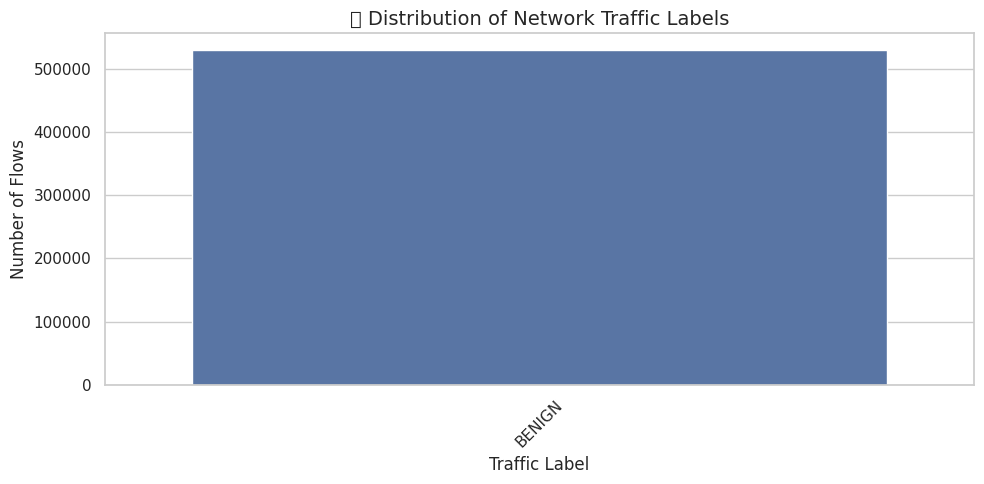

In [13]:
# ============================================================
# 🏷️ UNDERSTAND THE NETWORK TRAFFIC LABELS
# ============================================================

print("Distribution of network traffic labels:\n")

print(df[" Label"].value_counts())

# Visualize the label distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    x=df[" Label"],
    order=df[" Label"].value_counts().index
)

plt.title("📊 Distribution of Network Traffic Labels", fontsize=14)
plt.xlabel("Traffic Label")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 🧹 DATA CLEANING
# ============================================================

# ------------------------------------------------------------
# Step 1: Remove duplicate records
# ------------------------------------------------------------

initial_rows = len(df)

df = df.drop_duplicates()

removed_duplicates = initial_rows - len(df)

print(f"🗑️ Duplicate records removed: {removed_duplicates:,}")
print(f"📊 Remaining rows: {len(df):,}")

# ------------------------------------------------------------
# Step 2: Replace infinite values with NaN
# ------------------------------------------------------------

df = df.replace([np.inf, -np.inf], np.nan)

print("✅ Infinite values replaced with NaN.")

# ------------------------------------------------------------
# Step 3: Check for missing values
# ------------------------------------------------------------

print("🔎 Missing values in each column:\n")

missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
)

# ------------------------------------------------------------
# Step 4: Remove rows containing missing values
# ------------------------------------------------------------

before_dropna = len(df)

df = df.dropna()

removed_missing = before_dropna - len(df)

print(f"🗑️ Rows removed because of missing values: {removed_missing:,}")
print(f"📊 Final dataset shape: {df.shape}")

🗑️ Duplicate records removed: 26,935
📊 Remaining rows: 502,983
✅ Infinite values replaced with NaN.
🔎 Missing values in each column:



,0
Flow Bytes/s,333
Flow Packets/s,333


🗑️ Rows removed because of missing values: 333
📊 Final dataset shape: (502650, 79)


In [15]:
# ============================================================
# 🎯 SEPARATE LABELS FROM FEATURES
# ============================================================

# Store the actual network traffic labels
labels = df[" Label"].copy()

# Remove the label column from the feature dataset
x_processed_features = df.drop(columns=[" Label"])

print(f"🏷️ Labels shape   : {labels.shape}")
print(f"📊 Features shape : {x_processed_features.shape}")

🏷️ Labels shape   : (502650,)
📊 Features shape : (502650, 78)


In [16]:
# ============================================================
# 🧹 REMOVE UNSUITABLE / IDENTIFYING COLUMNS
# ============================================================

# These columns are not directly used by our model.
# They identify a connection rather than describing its
# numerical network behavior.

columns_to_remove = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

for column in columns_to_remove:

    if column in x_processed_features.columns:
        x_processed_features = x_processed_features.drop(
            columns=[column]
        )

print("✅ Unwanted columns removed.")
print(f"📊 Remaining columns: {x_processed_features.shape[1]}")

✅ Unwanted columns removed.
📊 Remaining columns: 78


In [17]:
# ============================================================
# 🔢 CONVERT FEATURES INTO NUMERIC FORMAT
# ============================================================

# Convert categorical columns into numerical dummy variables
x_processed_features = pd.get_dummies(
    x_processed_features
)

# Display data types
print("📊 Data types after encoding:\n")
print(
    x_processed_features.dtypes.value_counts()
)

# Convert all values to numeric
x_processed_features = x_processed_features.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace infinite values
x_processed_features = x_processed_features.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows containing NaN values
x_processed_features = x_processed_features.dropna()

print("✅ Features converted to numeric format.")
print(f"📊 Processed feature shape: {x_processed_features.shape}")

📊 Data types after encoding:

int64      54
float64    24
Name: count, dtype: int64
✅ Features converted to numeric format.
📊 Processed feature shape: (502650, 78)


In [18]:
# ============================================================
# 🎯 SELECT NETWORK TRAFFIC FEATURES
# ============================================================

# Selected network-flow features used by the model
features = [
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    "Total Length of Fwd Packets",
    " Total Length of Bwd Packets",
    "Flow Bytes/s",
    " Flow Packets/s",
    " Fwd Packet Length Mean",
    " Bwd Packet Length Mean"
]

# Create the final feature matrix
X = x_processed_features[features]

print("✅ Selected features:\n")

for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

print(f"\n📊 Final feature matrix shape: {X.shape}")

✅ Selected features:

1.  Flow Duration
2.  Total Fwd Packets
3.  Total Backward Packets
4. Total Length of Fwd Packets
5.  Total Length of Bwd Packets
6. Flow Bytes/s
7.  Flow Packets/s
8.  Fwd Packet Length Mean
9.  Bwd Packet Length Mean

📊 Final feature matrix shape: (502650, 9)


In [19]:
# ============================================================
# ⚖️ FEATURE SCALING
# ============================================================

# StandardScaler transforms the features so that they have
# a comparable scale before training the model.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Feature scaling completed!")
print(f"📊 Scaled data shape: {X_scaled.shape}")

✅ Feature scaling completed!
📊 Scaled data shape: (502650, 9)


In [20]:
# ============================================================
# 🌲 TRAIN ISOLATION FOREST
# ============================================================

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# Train the model
model.fit(X_scaled)

print("✅ Isolation Forest model trained successfully!")

✅ Isolation Forest model trained successfully!


In [21]:
# ============================================================
# 🔍 GENERATE ANOMALY PREDICTIONS
# ============================================================

# Isolation Forest returns:
#   1  → Normal
#  -1  → Anomaly

predictions = model.predict(X_scaled)

# Convert numerical predictions into readable labels
result = np.where(
    predictions == -1,
    "Anomaly",
    "Normal"
)

# Display the first 20 predictions
print("🔎 First 20 predictions:\n")
print(result[:20])

🔎 First 20 predictions:

['Normal' 'Anomaly' 'Normal' 'Anomaly' 'Normal' 'Normal' 'Anomaly'
 'Anomaly' 'Normal' 'Anomaly' 'Anomaly' 'Normal' 'Normal' 'Anomaly'
 'Normal' 'Normal' 'Normal' 'Anomaly' 'Anomaly' 'Anomaly']


In [22]:
# ============================================================
# 📈 CALCULATE ANOMALY SCORES
# ============================================================

# Lower scores indicate observations that are more unusual.

scores = model.decision_function(X_scaled)

# Create a DataFrame containing the results
results = pd.DataFrame({
    "Actual": labels,
    "Prediction": result,
    "Anomaly_Score": scores
})

print("📋 Sample prediction results:\n")

display(results.head(10))

📋 Sample prediction results:



,Actual,Prediction,Anomaly_Score
0,BENIGN,Normal,0.130490
1,BENIGN,Anomaly,-0.030228
4,BENIGN,Normal,0.118617
5,BENIGN,Anomaly,-0.030228
8,BENIGN,Normal,0.141492
9,BENIGN,Normal,0.044011
10,BENIGN,Anomaly,-0.041698
11,BENIGN,Anomaly,-0.045491
12,BENIGN,Normal,0.140919
13,BENIGN,Anomaly,-0.046949


In [23]:
# ============================================================
# 🏷️ CONVERT ACTUAL LABELS INTO NORMAL / ANOMALY
# ============================================================

# BENIGN traffic is considered Normal.
# All other labels are considered Anomaly.

actual = np.where(
    labels == "BENIGN",
    "Normal",
    "Anomaly"
)

# Convert labels into binary format:
# 0 → Normal
# 1 → Anomaly

y_true = np.where(
    labels == "BENIGN",
    0,
    1
)

# Convert model predictions into binary format:
# 0 → Normal
# 1 → Anomaly

y_pred = np.where(
    predictions == 1,
    0,
    1
)

print("✅ Actual and predicted labels prepared.")

✅ Actual and predicted labels prepared.


In [24]:
# ============================================================
# 📊 MODEL EVALUATION
# ============================================================

print("📊 Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Anomaly"]
    )
)

📊 Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    502650
     Anomaly       0.00      0.00      0.00         0

    accuracy                           0.95    502650
   macro avg       0.50      0.47      0.49    502650
weighted avg       1.00      0.95      0.97    502650



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_8980/1078759598.py:25: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


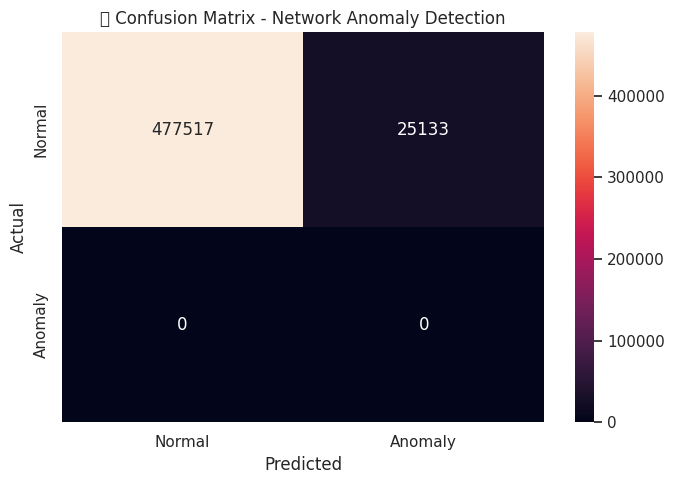

In [25]:
# ============================================================
# 🧩 CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("🧩 Confusion Matrix - Network Anomaly Detection")

plt.tight_layout()
plt.show()

/tmp/ipykernel_8980/1696701015.py:20: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


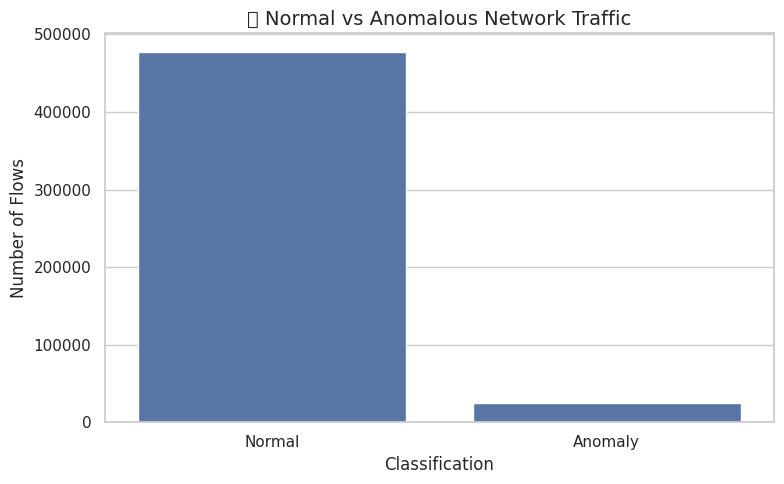

In [26]:
# ============================================================
# 📊 NORMAL VS ANOMALOUS NETWORK TRAFFIC
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=result,
    order=["Normal", "Anomaly"]
)

plt.title(
    "🚨 Normal vs Anomalous Network Traffic",
    fontsize=14
)

plt.xlabel("Classification")
plt.ylabel("Number of Flows")

plt.tight_layout()
plt.show()

/tmp/ipykernel_8980/3585007537.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


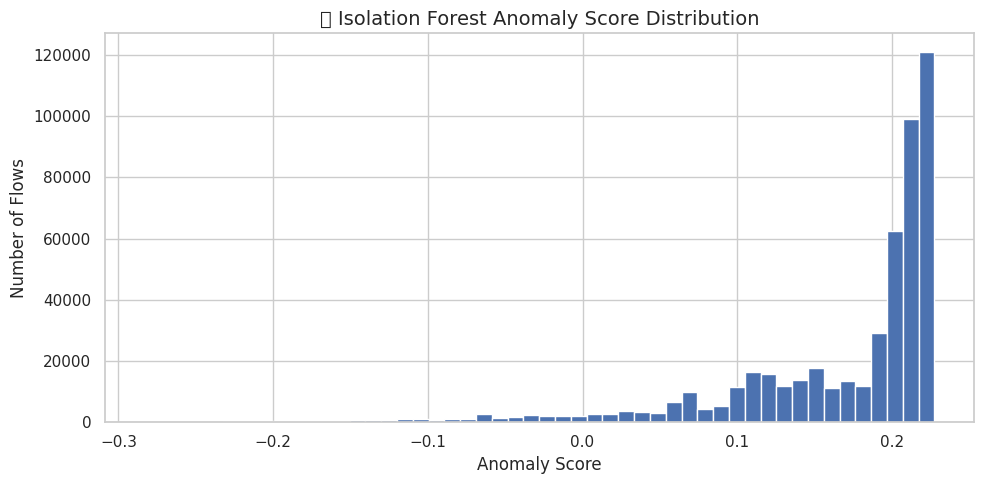

In [27]:
# ============================================================
# 📈 VISUALIZE ISOLATION FOREST ANOMALY SCORES
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    scores,
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flows")

plt.title(
    "📈 Isolation Forest Anomaly Score Distribution",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 💾 SAVE TRAINED MODEL AND SCALER
# ============================================================

# Create the model directory if it does not already exist
os.makedirs(
    "model",
    exist_ok=True
)

# Save the trained Isolation Forest model
joblib.dump(
    model,
    "model/isolation_forest.pkl"
)

# Save the scaler
joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("✅ Model saved successfully!")
print("📁 model/isolation_forest.pkl")

print("\n✅ Scaler saved successfully!")
print("📁 model/scaler.pkl")

✅ Model saved successfully!
📁 model/isolation_forest.pkl

✅ Scaler saved successfully!
📁 model/scaler.pkl


In [29]:
# ============================================================
# 🔎 VERIFY SAVED MODEL FILES
# ============================================================

print("📁 Saved model files:\n")

for file in os.listdir("model"):
    print(f"   ✅ {file}")

📁 Saved model files:

   ✅ scaler.pkl
   ✅ isolation_forest.pkl
